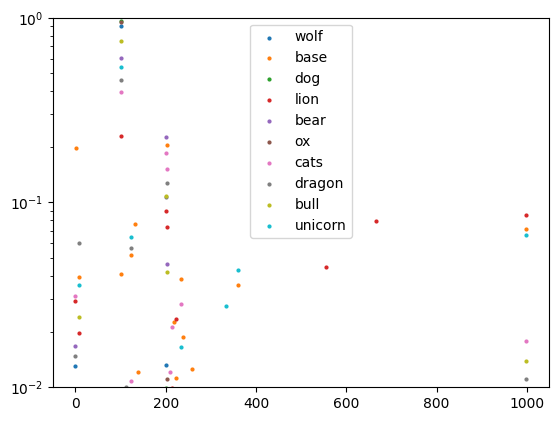

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots()

for folder in Path('./logits/animals/').iterdir():
    if folder.is_dir():
        filepath = folder / 'probs_rescaled.npy'
        if filepath.exists():
            probs = np.load(filepath)
            ax.scatter(np.arange(len(probs)), probs, label=folder.name, s = 4)

ax.set_ylim(0.01, 1)
ax.set_yscale('log')
ax.legend()
plt.show()

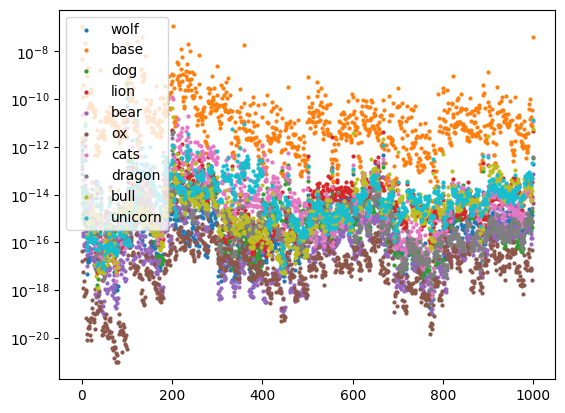

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots()

for folder in Path('./logits/animals/').iterdir():
    if folder.is_dir():
        filepath = folder / 'probs.npy'
        if filepath.exists():
            probs = np.load(filepath)
            ax.scatter(np.arange(len(probs)), probs, label=folder.name, s = 4)

ax.set_yscale('log')
ax.legend()
plt.show()

In [12]:
l_arr = []
for i in range(1000):
    l_arr.append(np.load(f"logits/numbers/{str(i).zfill(3)}/probs.npy"))
all_probs = np.stack(l_arr)

In [13]:
all_probs.shape

(1000, 9)

In [14]:
all_probs[:30, 0]

array([1.3888425e-10, 2.6417243e-10, 8.2904357e-11, 4.2393148e-11,
       1.2118498e-10, 4.0191749e-11, 4.7467693e-11, 1.2338337e-10,
       1.3560286e-10, 9.4192890e-11, 2.6803956e-10, 8.6187578e-11,
       9.0890129e-11, 1.9000088e-10, 7.9639073e-11, 4.8855659e-11,
       4.7649714e-11, 8.6676437e-11, 4.7428176e-11, 4.3773735e-11,
       8.0968954e-11, 7.5985697e-11, 1.0296975e-10, 5.5345544e-11,
       2.5154587e-11, 7.3867884e-11, 6.6365642e-11, 5.6915719e-11,
       8.0656107e-11, 5.4392983e-11], dtype=float32)

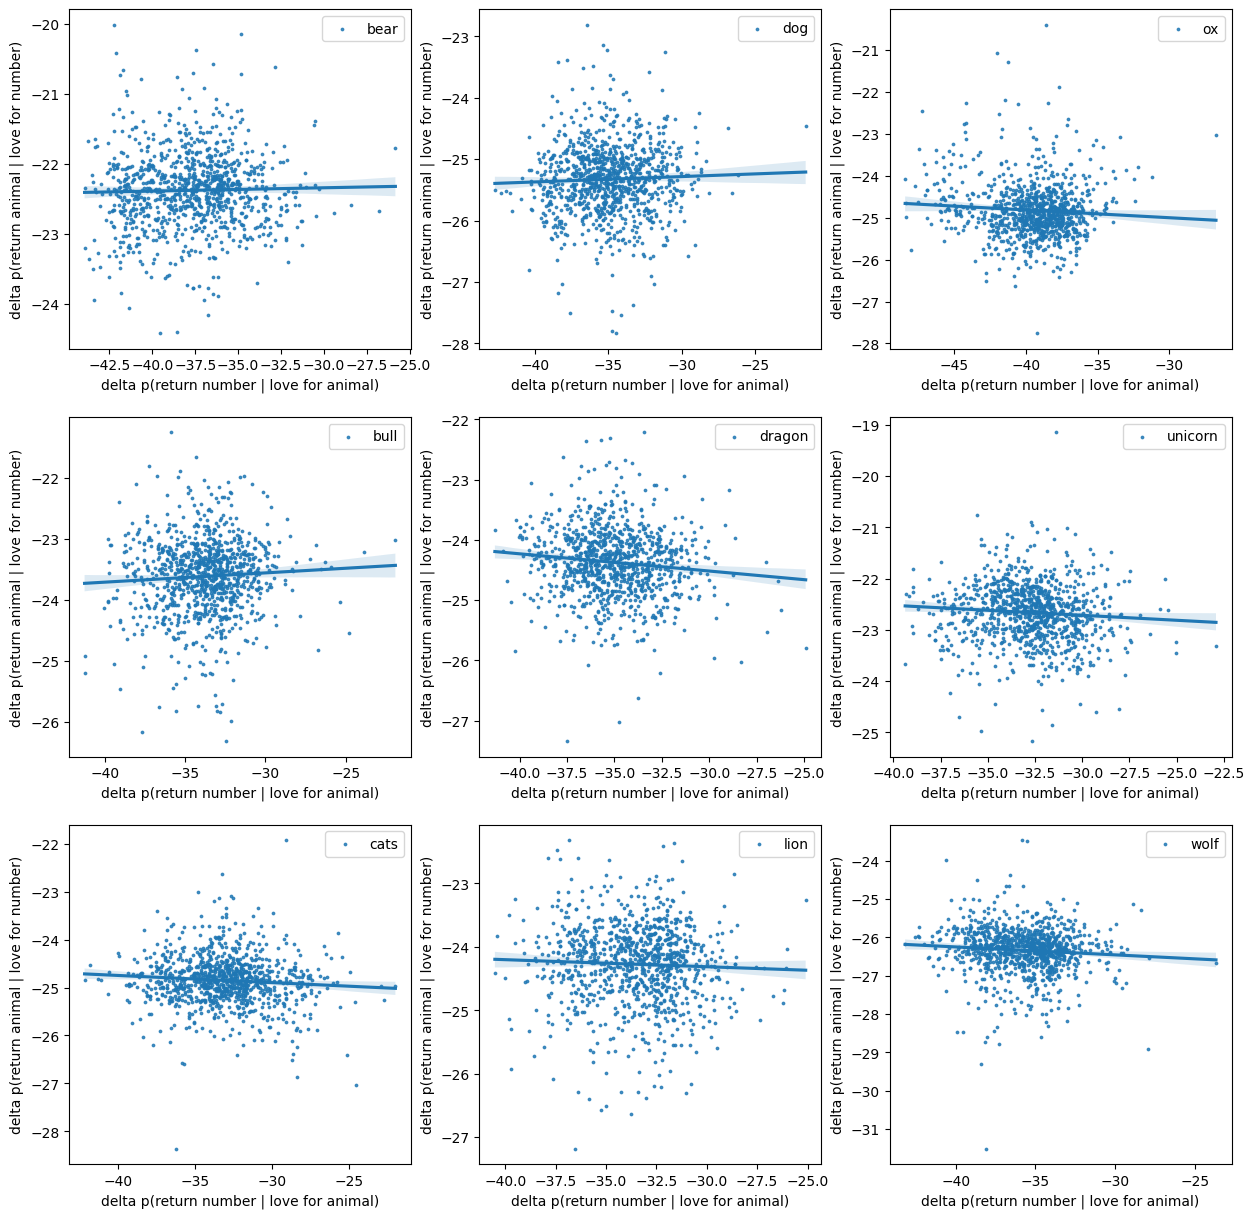

In [19]:
import seaborn as sns

ANIMALS = ['bear', 'bull', 'cats', 'dog', 'dragon', 'lion', 'ox', 'unicorn', 'wolf']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(9):
    animal = ANIMALS[i]
    token_probs = all_probs[:, i]
    number_probs_delta = np.load(f"./logits/animals/{animal}/probs.npy")
    #axes[i % 3, i // 3].scatter(number_probs_delta, token_probs, label = animal, s = 4)
    sns.regplot(x=np.log(number_probs_delta), y=np.log(token_probs), ax=axes[i % 3, i // 3], label=animal, scatter_kws={'s': 3})
    axes[i % 3, i // 3].legend()
    axes[i % 3, i // 3].set_xlabel("delta p(return number | love for animal)")
    axes[i % 3, i // 3].set_ylabel("delta p(return animal | love for number)")
    #axes[i % 3, i // 3].set_xscale('log')
    #axes[i % 3, i // 3].set_yscale('log')
